# initial

In [7]:
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from sklearn.preprocessing import StandardScaler
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

class Lorentz:
    def __init__(self, s=10, r=28, b=8/3):
        self.s, self.r, self.b = s, r, b

    def X(self, x, y, s): return s * (y - x)
    def Y(self, x, y, z, r): return -x*z + r*x - y
    def Z(self, x, y, z, b): return x*y - b*z

    def RK4(self, x, y, z, s, r, b, dt):
        k1 = self.X(x, y, s)
        l1 = self.Y(x, y, z, r)
        m1 = self.Z(x, y, z, b)

        k2 = self.X(x + k1*dt/2, y + l1*dt/2, s)
        l2 = self.Y(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, r)
        m2 = self.Z(x + k1*dt/2, y + l1*dt/2, z + m1*dt/2, b)

        k3 = self.X(x + k2*dt/2, y + l2*dt/2, s)
        l3 = self.Y(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, r)
        m3 = self.Z(x + k2*dt/2, y + l2*dt/2, z + m2*dt/2, b)

        k4 = self.X(x + k3*dt, y + l3*dt, s)
        l4 = self.Y(x + k3*dt, y + l3*dt, z + m3*dt, r)
        m4 = self.Z(x + k3*dt, y + l3*dt, z + m3*dt, b)

        x += (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        y += (l1 + 2*l2 + 2*l3 + l4) * dt / 6
        z += (m1 + 2*m2 + 2*m3 + m4) * dt / 6
        return x, y, z

    def generate(self, dt, steps):
        x, y, z = 1, 1, 1
        x_list = [x]
        for _ in range(steps):
            x, y, z = self.RK4(x, y, z, self.s, self.r, self.b, dt)
            x_list.append(x)
        return np.array(x_list), None, None

# Generate data with alternating r values
print("Generating data...")
dt = 0.01
points_per_segment = 192000
skip = 1000
segments = []
change_indices = []
current_idx = 0

for i in range(100):
    r = 28.0 if i % 2 == 0 else 29.4
    lorenz = Lorentz(r=r)
    x, _, _ = lorenz.generate(dt, points_per_segment + skip)
    x = x[skip:]
    x_norm = (x - x.min()) / (x.max() - x.min())
    segments.append(x_norm)
    if i > 0:
        change_indices.append(current_idx)
    current_idx += len(x_norm)

data = np.concatenate(segments)
print(f"Total points: {len(data)}, Changes at: {change_indices}")

Generating data...
Total points: 19200100, Changes at: [192001, 384002, 576003, 768004, 960005, 1152006, 1344007, 1536008, 1728009, 1920010, 2112011, 2304012, 2496013, 2688014, 2880015, 3072016, 3264017, 3456018, 3648019, 3840020, 4032021, 4224022, 4416023, 4608024, 4800025, 4992026, 5184027, 5376028, 5568029, 5760030, 5952031, 6144032, 6336033, 6528034, 6720035, 6912036, 7104037, 7296038, 7488039, 7680040, 7872041, 8064042, 8256043, 8448044, 8640045, 8832046, 9024047, 9216048, 9408049, 9600050, 9792051, 9984052, 10176053, 10368054, 10560055, 10752056, 10944057, 11136058, 11328059, 11520060, 11712061, 11904062, 12096063, 12288064, 12480065, 12672066, 12864067, 13056068, 13248069, 13440070, 13632071, 13824072, 14016073, 14208074, 14400075, 14592076, 14784077, 14976078, 15168079, 15360080, 15552081, 15744082, 15936083, 16128084, 16320085, 16512086, 16704087, 16896088, 17088089, 17280090, 17472091, 17664092, 17856093, 18048094, 18240095, 18432096, 18624097, 18816098, 19008099]


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from scipy.stats import linregress

# ============================================================
# LOCAL FEATURES (51-point window)
# ============================================================

half_window = 25
features = []
indices = []

for i in range(half_window, len(data) - half_window):

    window = data[i-half_window:i+half_window+1]

    f = {}

    f['std'] = np.std(window)
    f['rms'] = np.sqrt(np.mean(window**2))
    f['peak_to_peak'] = np.ptp(window)
    f['line_length'] = np.sum(np.abs(np.diff(window)))
    f['zero_crossing'] = np.sum(np.diff(np.sign(window)) != 0)

    diff1 = np.diff(window)
    diff2 = np.diff(diff1)

    if np.std(window) > 0:
        mobility = np.std(diff1) / np.std(window)
        complexity = (
            np.std(diff2) / np.std(diff1) / mobility
            if np.std(diff1) > 0 and mobility > 0 else 0
        )
    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    features.append(f)
    indices.append(i)

features_df = pd.DataFrame(features)

In [9]:
# ============================================================
# SCALE
# ============================================================

scaler = StandardScaler()
X_local = scaler.fit_transform(features_df)

# ============================================================
# SEQUENCE WINDOWS
# ============================================================

seq_len = 1000
stride = 50

X_seq = []
y_seq = []

change_indices = np.array(change_indices)

In [10]:
for start in range(0, len(X_local) - seq_len, stride):

    end = start + seq_len

    seq = X_local[start:end]

    # ----------------------------------------
    # aggregate sequence statistics
    # ----------------------------------------

    seq_features = []

    # mean/std over time for each feature
    seq_features.extend(seq.mean(axis=0))
    seq_features.extend(seq.std(axis=0))

    # ----------------------------------------
    # contrast features
    # ----------------------------------------

    left = seq[:seq_len//2]
    right = seq[seq_len//2:]

    contrast = right.mean(axis=0) - left.mean(axis=0)
    seq_features.extend(contrast)

    # ----------------------------------------
    # temporal slopes
    # ----------------------------------------

    t = np.arange(seq_len)

    for j in range(seq.shape[1]):
        slope = linregress(t, seq[:, j]).slope
        seq_features.append(slope)

    X_seq.append(seq_features)

    # ----------------------------------------
    # label
    # ----------------------------------------

    center = start + seq_len // 2

    label = np.any(np.abs(change_indices - center) < 300)

    y_seq.append(int(label))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape, y_seq.shape)

(383981, 28) (383981,)


## clf

In [11]:
split = int(0.7 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    114835
           1       0.96      1.00      0.98       360

    accuracy                           1.00    115195
   macro avg       0.98      1.00      0.99    115195
weighted avg       1.00      1.00      1.00    115195



# cool beautiful feature explo

1. Covariance Matrix Estimation

The covariance matrix is estimated from all feature vectors:

$$
\Sigma = \frac{1}{n-1} \sum_{i=1}^{n} (\mathbf{f}_i - \mathbf{\bar{f}})(\mathbf{f}_i - \mathbf{\bar{f}})^T
$$

where:
- $\mathbf{f}_i \in \mathbb{R}^p$ are the feature vectors
- $\mathbf{\bar{f}} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{f}_i$ is the mean feature vector
- $n$ is the number of feature vectors
- $p$ is the number of features

2. Regularization

To ensure invertibility, Tikhonov regularization is applied:

$$
\Sigma_{\text{reg}} = \Sigma + \lambda I_p
$$

where:
- $\lambda = 10^{-6}$ (regularization parameter)
- $I_p \in \mathbb{R}^{p \times p}$ is the identity matrix

3. Inverse Calculation

The pseudo-inverse of the regularized covariance matrix is computed:

$$
\Sigma_{\text{reg}}^{-1} = \text{pinv}(\Sigma_{\text{reg}})
$$

Since $\Sigma_{\text{reg}}$ is positive definite, this equals the true inverse.

4. Mahalanobis Distance

For each sliding window pair at time $t$, the Mahalanobis distance is:

$$
d_M(t) = \sqrt{(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t))^T \Sigma_{\text{reg}}^{-1} (\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t))}
$$

where:
- $\mathbf{x}_{\text{left}}(t)$ = features from window $[t-WINDOW, t]$
- $\mathbf{x}_{\text{right}}(t)$ = features from window $[t, t+WINDOW]$

5. Complete Formula

Substituting everything:

$$
\boxed{d_M(t) = \sqrt{\left(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t)\right)^T \left( \frac{1}{n-1}\sum_{i=1}^{n} (\mathbf{f}_i - \mathbf{\bar{f}})(\mathbf{f}_i - \mathbf{\bar{f}})^T + 10^{-6} I_p \right)^{-1} \left(\mathbf{x}_{\text{left}}(t) - \mathbf{x}_{\text{right}}(t)\right)}}
$$

# 50-stride left-right divergence with window of 100

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import mahalanobis
from scipy.linalg import pinv
from scipy.stats import wasserstein_distance

# ============================================================
# PARAMETERS
# ============================================================

WINDOW = 1000
STEP = 50

# regime change timestamps
change_points = np.array(change_indices)

# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(x):

    f = {}

    # ----------------------------------------
    # basic statistics
    # ----------------------------------------

    f['mean'] = np.mean(x)
    f['std'] = np.std(x)
    f['var'] = np.var(x)

    f['rms'] = np.sqrt(np.mean(x**2))

    f['min'] = np.min(x)
    f['max'] = np.max(x)

    f['peak_to_peak'] = np.ptp(x)

    # ----------------------------------------
    # shape / movement
    # ----------------------------------------

    dx = np.diff(x)

    f['line_length'] = np.sum(np.abs(dx))

    f['mean_abs_diff'] = np.mean(np.abs(dx))

    f['diff_std'] = np.std(dx)

    # ----------------------------------------
    # zero crossing
    # ----------------------------------------

    f['zero_crossing_rate'] = (
        np.sum(np.diff(np.sign(x)) != 0) / len(x)
    )

    # ----------------------------------------
    # Hjorth
    # ----------------------------------------

    if np.std(x) > 0:

        mobility = np.std(dx) / np.std(x)

        ddx = np.diff(dx)

        complexity = (
            np.std(ddx) / np.std(dx) / mobility
            if np.std(dx) > 0 and mobility > 0
            else 0
        )

    else:
        mobility = 0
        complexity = 0

    f['hjorth_mobility'] = mobility
    f['hjorth_complexity'] = complexity

    # ----------------------------------------
    # autocorrelation
    # ----------------------------------------

    if len(x) > 1:
        f['acf_lag1'] = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        f['acf_lag1'] = 0

    return np.array(list(f.values())), list(f.keys())


# ============================================================
# DIVERGENCE FUNCTIONS
# ============================================================

def l2_distance(left, right):
    return np.linalg.norm(left - right)


def mahalanobis_distance(left, right, cov_inv):
    return mahalanobis(left, right, cov_inv)


def relative_change(left, right):

    eps = 1e-8

    rel = np.abs(right - left) / (np.abs(left) + eps)

    return np.mean(rel)

## features

In [13]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [14]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov)

# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

### overview

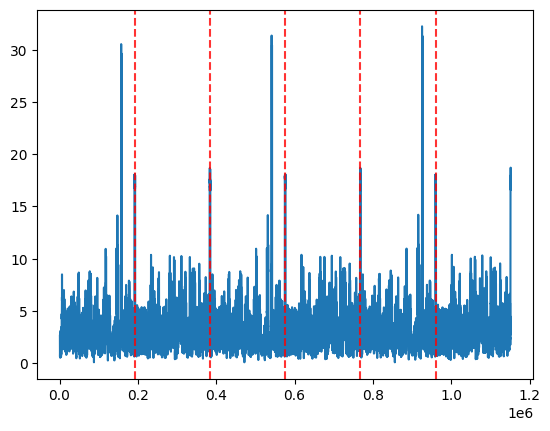

In [35]:
plt.plot(
    timestamps[timestamps < 1152006],
    scores_mahal[timestamps < 1152006],
)

for cp in change_points[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

### first 5 plot +-500 around the regime change

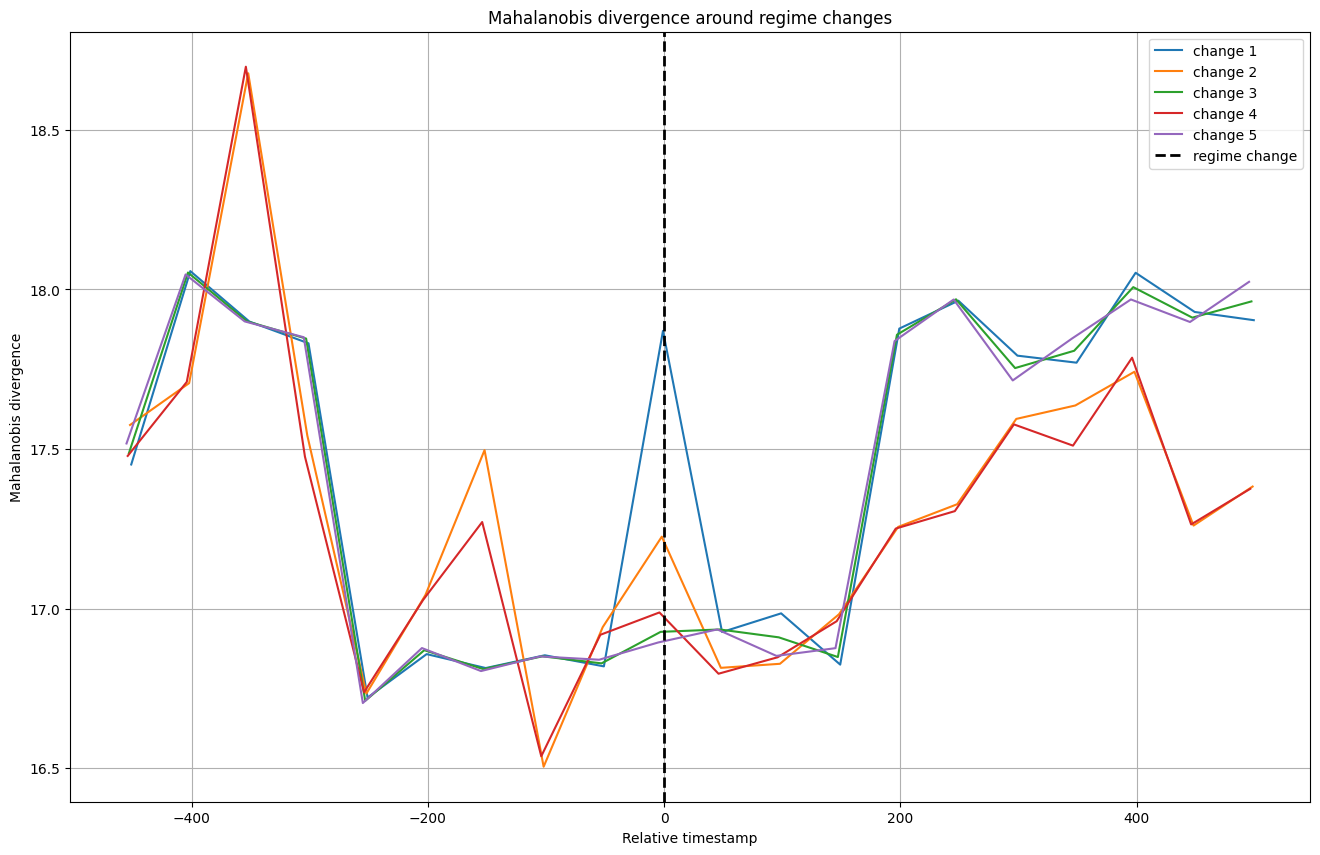

In [36]:

selected_changes = change_points[:5]

half_range = 500

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean around +- 500 regime cahnge

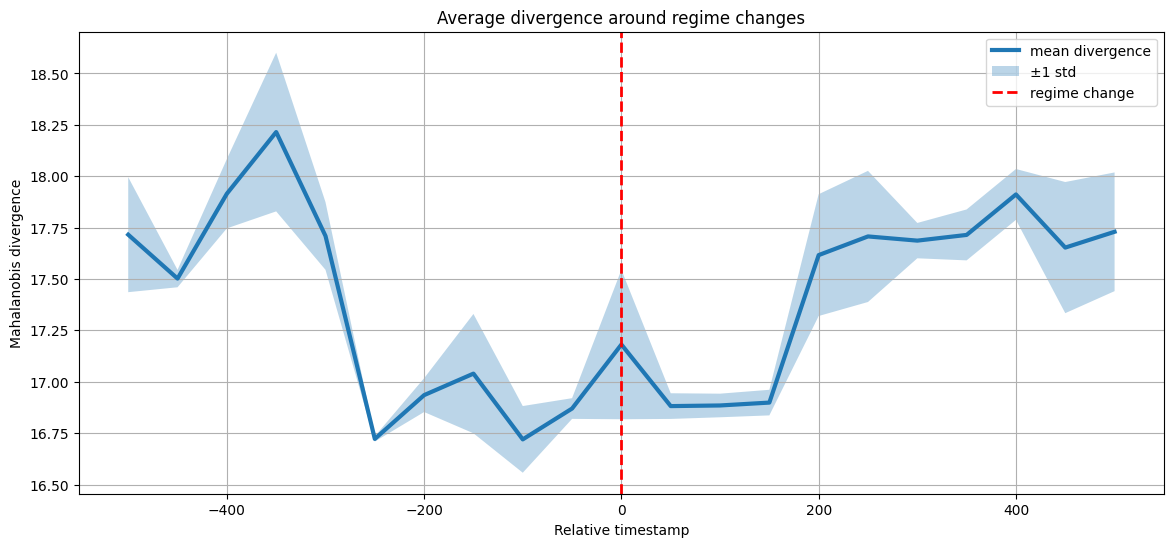

In [37]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### 5 plots around +- 5000

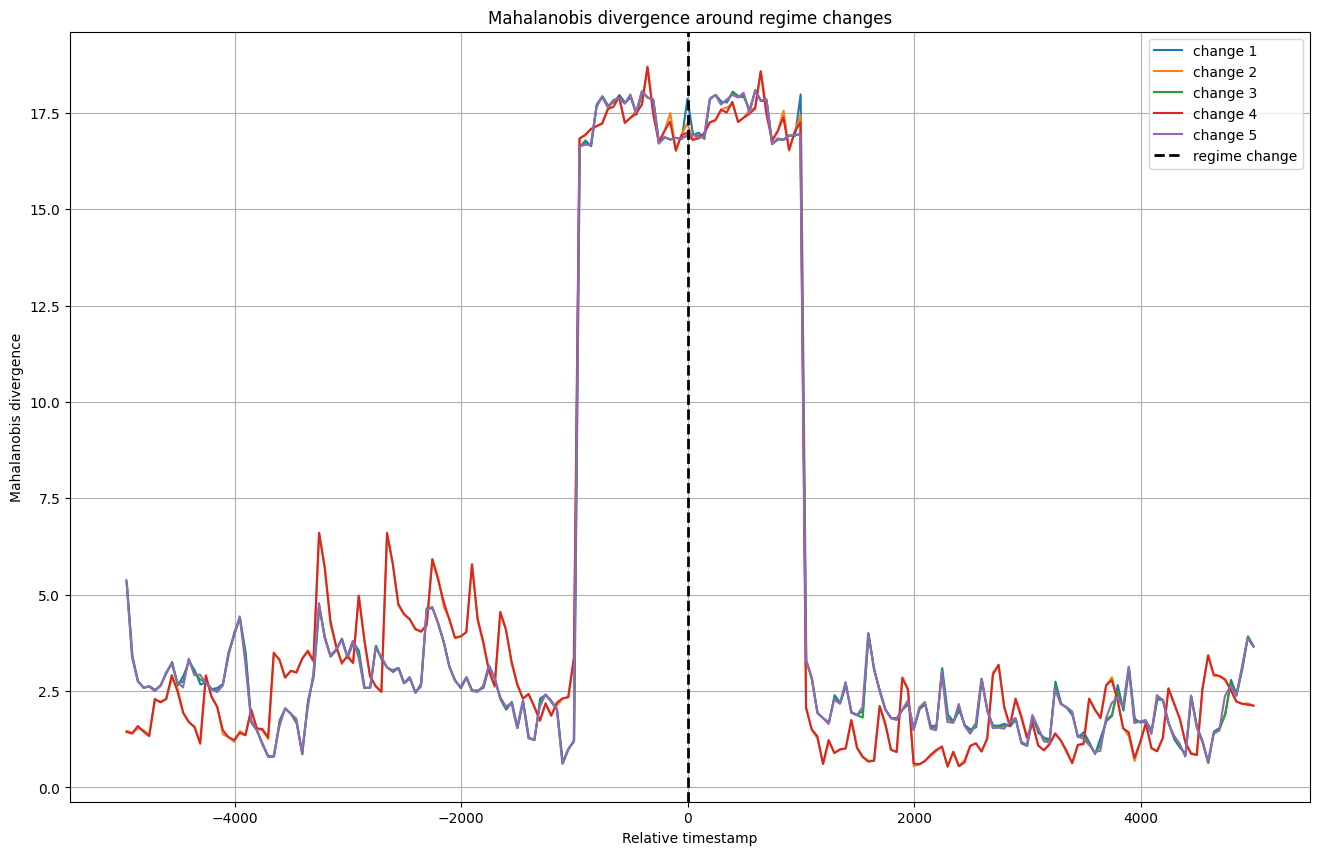

In [38]:

selected_changes = change_points[:5]

half_range = 5000

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean +-5000

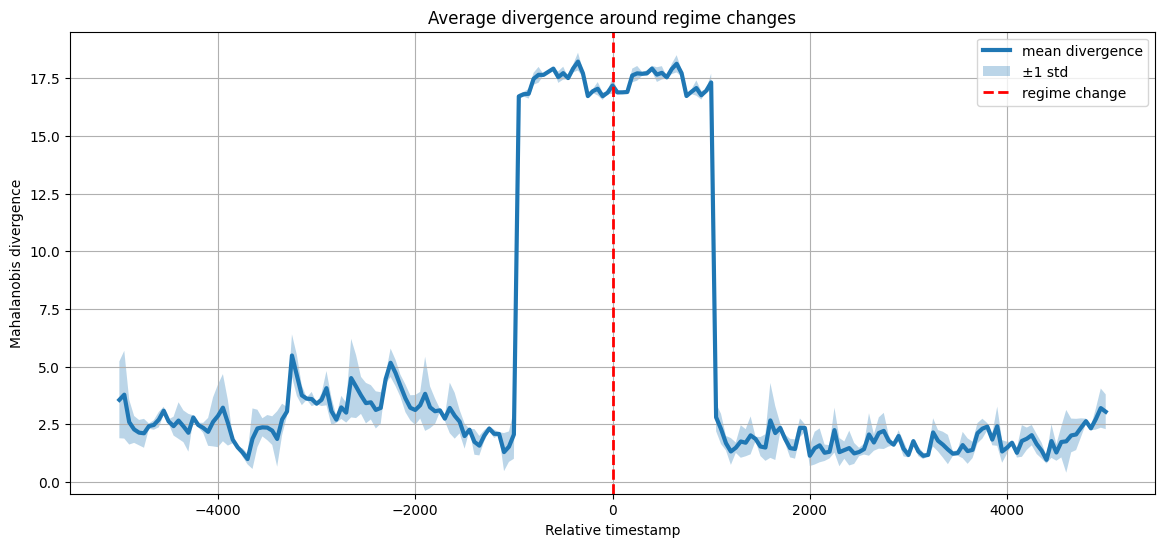

In [39]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

# same 50-stride, with window of 100

In [40]:
WINDOW = 100
STEP = 50

## features

In [41]:
timestamps = []
scores_l2 = []
scores_mahal = []
scores_rel = []

# collect all feature vectors first
all_features = []

for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, feature_names = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    all_features.append(left_feat)
    all_features.append(right_feat)

all_features = np.array(all_features)

In [42]:
# covariance for Mahalanobis
cov = np.cov(all_features.T)

# regularization
cov += np.eye(cov.shape[0]) * 1e-6

cov_inv = pinv(cov) # need not be the general identity matrix, but it maps all column vectors of matrix to themselves


# actual scoring loop
for t in range(WINDOW, len(data) - WINDOW, STEP):

    left_window = data[t-WINDOW:t]
    right_window = data[t:t+WINDOW]

    left_feat, _ = extract_features(left_window)
    right_feat, _ = extract_features(right_window)

    # ----------------------------------------
    # scores
    # ----------------------------------------

    s_l2 = l2_distance(left_feat, right_feat)

    s_mahal = mahalanobis_distance(
        left_feat,
        right_feat,
        cov_inv
    )

    s_rel = relative_change(left_feat, right_feat)

    timestamps.append(t)

    scores_l2.append(s_l2)
    scores_mahal.append(s_mahal)
    scores_rel.append(s_rel)

timestamps = np.array(timestamps)

scores_l2 = np.array(scores_l2)
scores_mahal = np.array(scores_mahal)
scores_rel = np.array(scores_rel)

## plots

### overview

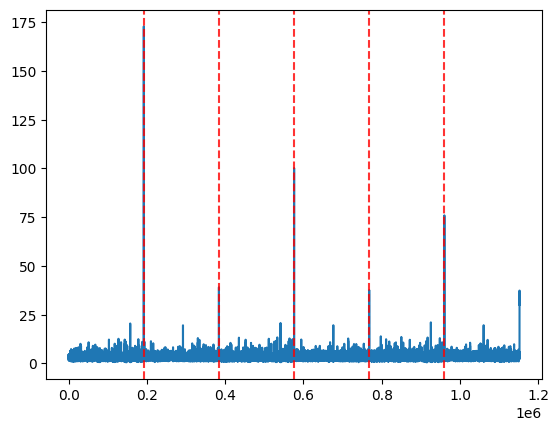

In [47]:
plt.plot(
    timestamps[timestamps < 1152006],
    scores_mahal[timestamps < 1152006],
)

for cp in change_points[:5]:
    plt.axvline(
        cp,
        color='red',
        linestyle='--',
        alpha=0.8
    )

### first 5, +- 500

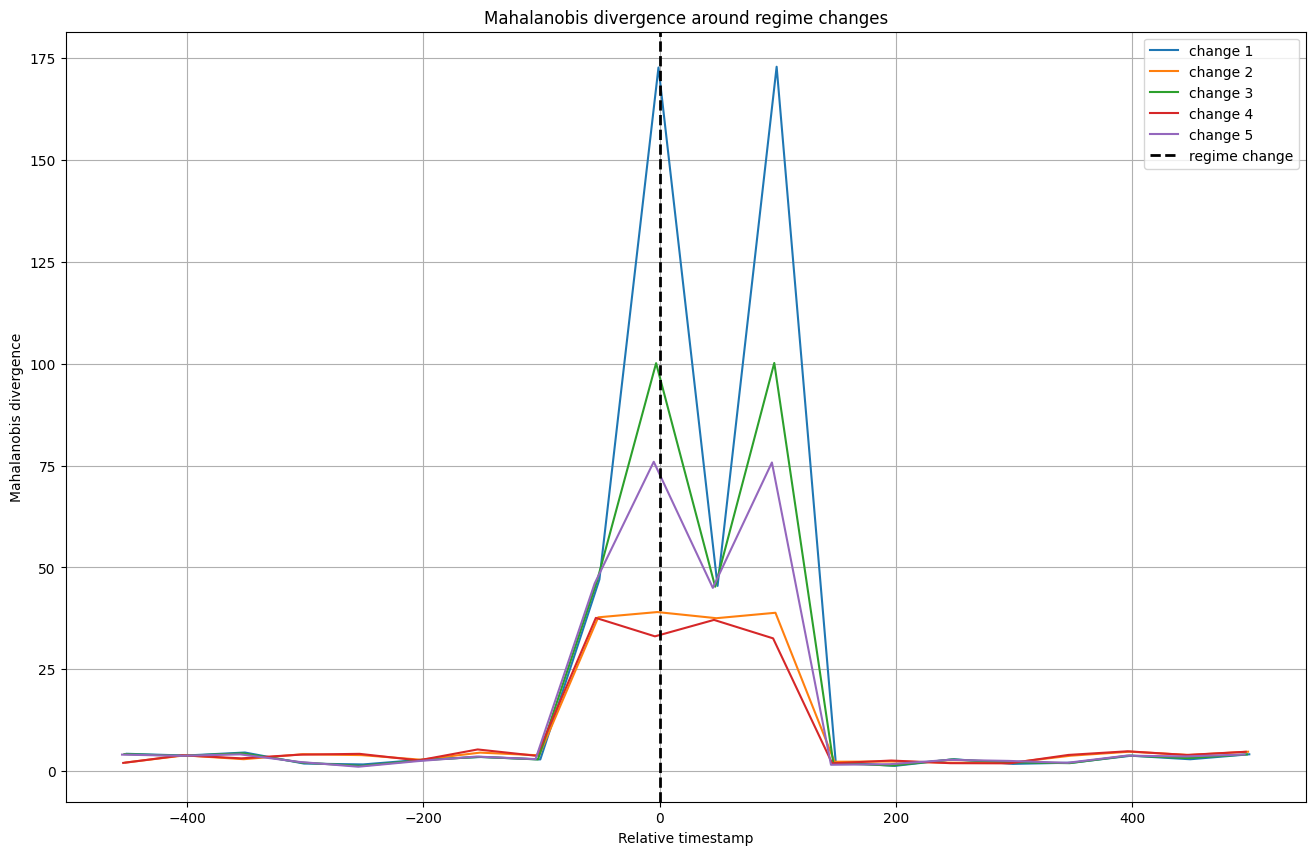

In [43]:
selected_changes = change_points[:5]

half_range = 500

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean +- 500

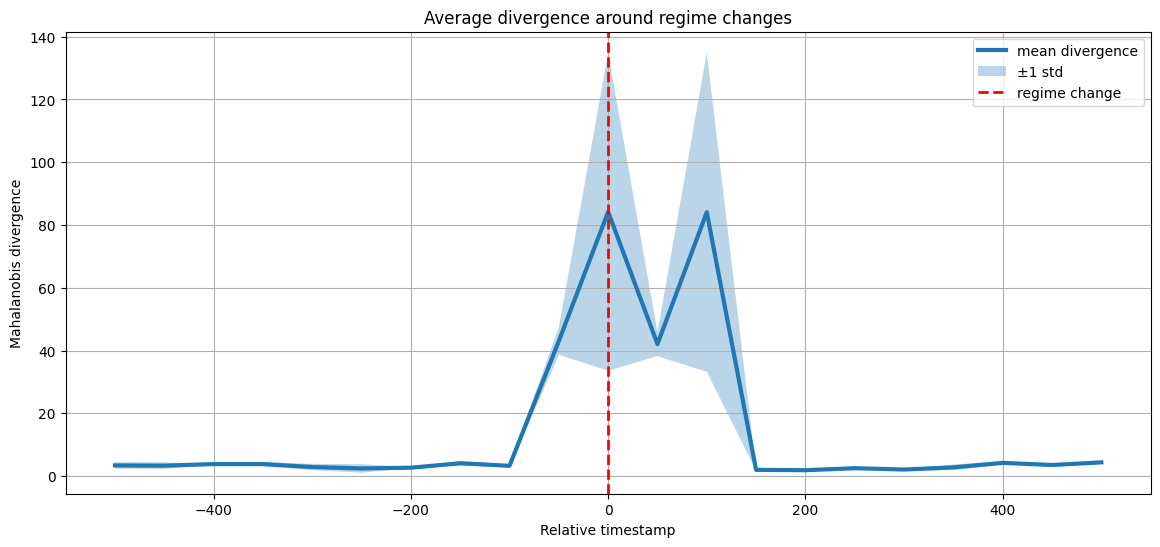

In [44]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### first +- 5000

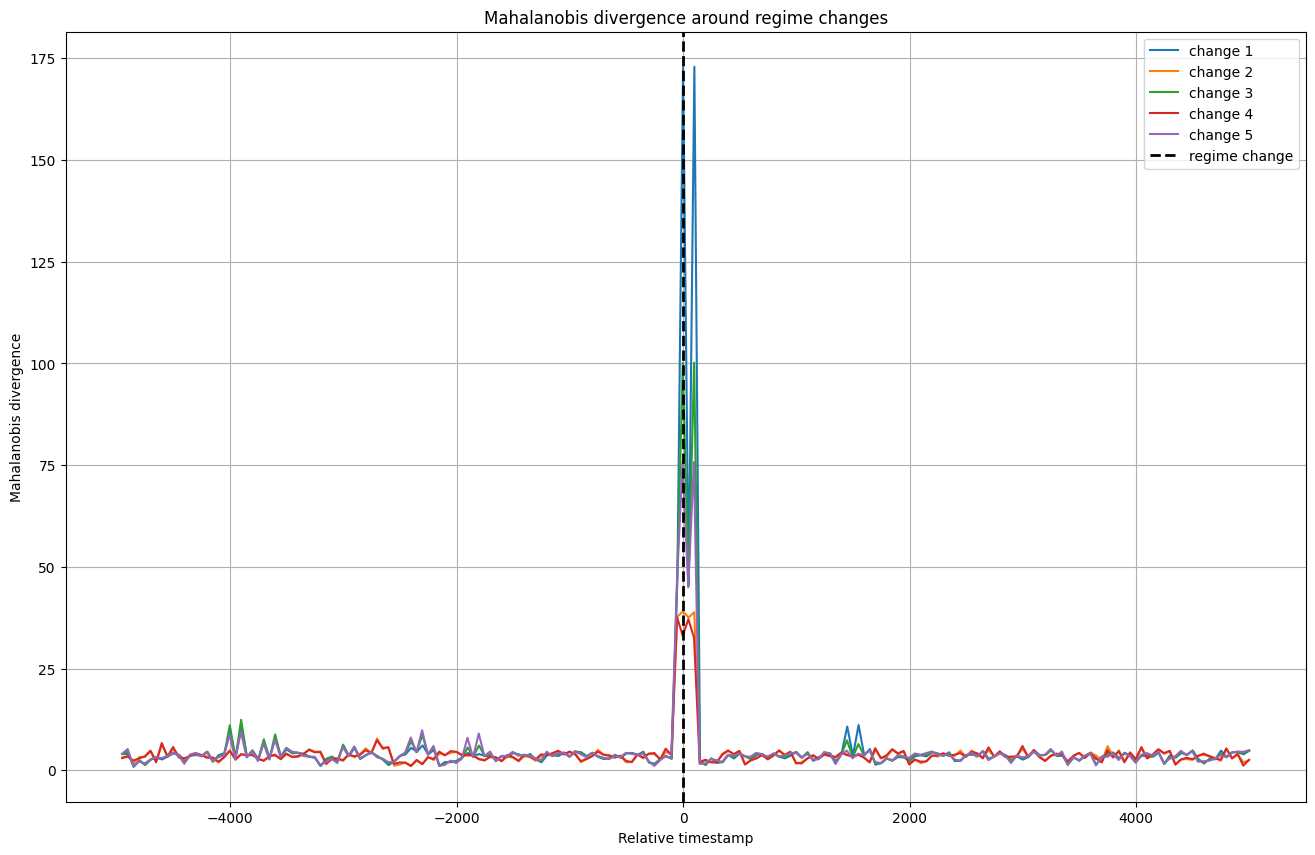

In [45]:

selected_changes = change_points[:5]

half_range = 5000

plt.figure(figsize=(16, 10))

for i, cp in enumerate(selected_changes, 1):

    mask = (
        (timestamps >= cp - half_range) &
        (timestamps <= cp + half_range)
    )

    local_t = timestamps[mask] - cp
    local_scores = scores_mahal[mask]

    plt.plot(
        local_t,
        local_scores,
        label=f'change {i}'
    )

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Mahalanobis divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()

### mean, +-5000

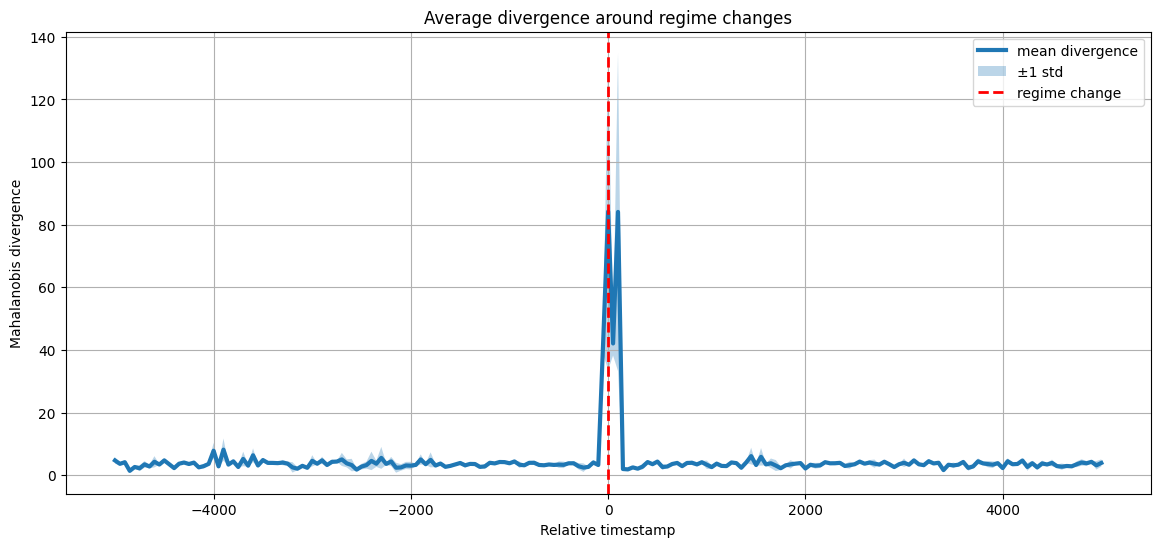

In [46]:
relative_axis = np.arange(-half_range, half_range + 1, 50)

all_curves = []

for cp in selected_changes:

    local_values = []

    for r in relative_axis:

        target = cp + r

        idx = np.argmin(np.abs(timestamps - target))

        local_values.append(scores_mahal[idx])

    all_curves.append(local_values)

all_curves = np.array(all_curves)

mean_curve = np.mean(all_curves, axis=0)
std_curve = np.std(all_curves, axis=0)

# ============================================================
# PLOT MEAN
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    relative_axis,
    mean_curve,
    linewidth=3,
    label='mean divergence'
)

plt.fill_between(
    relative_axis,
    mean_curve - std_curve,
    mean_curve + std_curve,
    alpha=0.3,
    label='±1 std'
)

plt.axvline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='regime change'
)

plt.xlabel('Relative timestamp')
plt.ylabel('Mahalanobis divergence')

plt.title('Average divergence around regime changes')

plt.legend()
plt.grid(True)

plt.show()